In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
df = pd.read_csv('healthexp.csv')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             304 non-null    int64  
 1   Country          304 non-null    object 
 2   Spending_USD     304 non-null    float64
 3   Life_Expectancy  304 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.6+ KB
None
   Year        Country  Spending_USD  Life_Expectancy
0  1970        Germany       252.311             70.6
1  1970         France       192.143             72.2
2  1970  Great Britain       123.993             71.9
3  1970          Japan       150.437             72.0
4  1970            USA       326.961             70.9


##הכנת הנתונים (Preprocessing)

In [22]:
df = df.dropna()

df_encoded = pd.get_dummies(df, columns=['Country'], drop_first=True)

correlations = df_encoded.corr()['Life_Expectancy'].sort_values(ascending=False)
print("Correlations with Life Expectancy:")
print(correlations)

X = df_encoded.drop('Life_Expectancy', axis=1)
y = df_encoded['Life_Expectancy']

Correlations with Life Expectancy:
Life_Expectancy          1.000000
Year                     0.891633
Spending_USD             0.585438
Country_Japan            0.248980
Country_France           0.206684
Country_Great Britain   -0.015588
Country_Germany         -0.198444
Country_USA             -0.295063
Name: Life_Expectancy, dtype: float64


##חלוקה לסט אימון ובדיקה ונרמול (Scaling)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

##אימון מודלים והשוואת ביצועים

In [24]:
# רגרסיה ליניארית
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# KNN 
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))

print(f"Linear Regression: {lr_rmse:.4f}")
print(f"KNN Regressor: {knn_rmse:.4f}")

if knn_rmse < lr_rmse:
    final_model = knn_model
    print("Winner: KNN Regressor")
else:
    final_model = lr_model
    print("Winner: Linear Regression")

Linear Regression: 0.5051
KNN Regressor: 0.4923
Winner: KNN Regressor


In [29]:
cv_scores = cross_val_score(final_model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"The index of the model's fit to reality: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

The index of the model's fit to reality: 0.9526
Standard Deviation: 0.0283


In [26]:
coefficients = pd.DataFrame(lr_model.coef_, X.columns, columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False))

                       Coefficient
Year                      4.134384
Country_Japan             0.527399
Country_France           -0.000170
Country_USA              -0.217798
Country_Germany          -0.431588
Country_Great Britain    -0.582765
Spending_USD             -1.525955


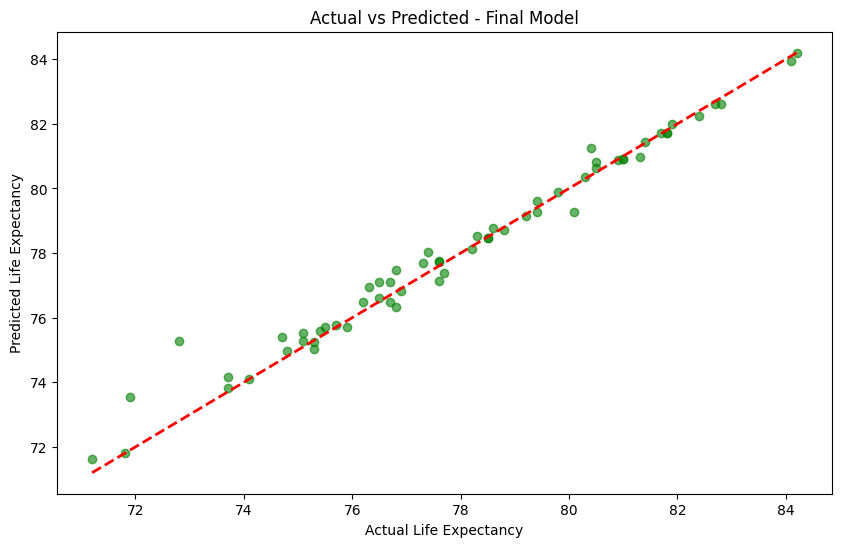

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_model.predict(X_test_scaled), alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Actual vs Predicted - Final Model')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.show()

##שמירת המודל והסקיילר לשימוש באפליקציה

In [28]:
# שמירת המודל המנצח
joblib.dump(final_model, 'model.pkl')

# שמירת הסקיילר
joblib.dump(scaler, 'scaler.pkl')

# שמירת שמות העמודות
joblib.dump(X.columns.tolist(), 'columns.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
print("All files saved: model.pkl, scaler.pkl, columns.pkl")

All files saved: model.pkl, scaler.pkl, columns.pkl
